In [1]:
!wget https://iasl-btm.iis.sinica.edu.tw/BNER/Content/Revised_JNLPBA.zip

--2025-10-15 01:40:07--  https://iasl-btm.iis.sinica.edu.tw/BNER/Content/Revised_JNLPBA.zip
Resolving iasl-btm.iis.sinica.edu.tw (iasl-btm.iis.sinica.edu.tw)... 140.109.20.133
Connecting to iasl-btm.iis.sinica.edu.tw (iasl-btm.iis.sinica.edu.tw)|140.109.20.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2533317 (2.4M) [application/x-zip-compressed]
Saving to: ‘Revised_JNLPBA.zip’

Revised_JNLPBA.zip  100%[===================>]   2.42M  1.43MB/s    in 1.7s    

2025-10-15 01:40:10 (1.43 MB/s) - ‘Revised_JNLPBA.zip’ saved [2533317/2533317]



In [2]:
!unzip -n Revised_JNLPBA.zip -d Revised_JNLPBA

Archive:  Revised_JNLPBA.zip
  inflating: Revised_JNLPBA/Genia4EReval1.iob2  
  inflating: Revised_JNLPBA/Genia4EReval2.iob2  
  inflating: Revised_JNLPBA/Genia4ERtask1.iob2  
  inflating: Revised_JNLPBA/Genia4ERtask2.iob2  


In [3]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 932.3 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=9bb7c89c170f73d387240c93bb92c810f05446115ae68b4023ce8bc2eb3437c2
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


In [4]:
from typing import List, Tuple
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from collections import Counter
from itertools import chain

In [5]:
import re  # Untuk pencocokan pola teks (regex)

# Fungsi untuk membaca file IOB dan mengubahnya jadi daftar kalimat dan label
def read_iob(file_path):
    sentences, labels = [], []   # Menyimpan kumpulan kalimat dan label
    tokens, tags = [], []        # Menyimpan token dan tag sementara
    header_pattern = re.compile(r"^###MEDLINE:\d+")  # Pola untuk melewati baris header

    with open(file_path, "r") as f:  # Membuka file dan membaca baris per baris
        for line in f:
            line = line.strip()
            if not line:  # Jika baris kosong → akhir kalimat
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
                continue

            if header_pattern.match(line):  # Lewati baris header
                continue

            parts = line.split()
            if len(parts) == 2:  # Pisahkan kata dan tag
                word, tag = parts
                tokens.append(word)
                tags.append(tag)

        # Simpan kalimat terakhir jika belum ditutup baris kosong
        if tokens:
            sentences.append(tokens)
            labels.append(tags)

    return sentences, labels  # Kembalikan list kalimat dan label


# Membaca empat file dataset JNLPBA (dua untuk training, dua untuk evaluasi)
train_sent1, train_labels1 = read_iob("Revised_JNLPBA/Genia4ERtask1.iob2")
train_sent2, train_labels2 = read_iob("Revised_JNLPBA/Genia4ERtask2.iob2")
eval_sent1, eval_labels1   = read_iob("Revised_JNLPBA/Genia4EReval1.iob2")
eval_sent2, eval_labels2   = read_iob("Revised_JNLPBA/Genia4EReval2.iob2")

# Menggabungkan data training dan evaluasi
train_sentences = train_sent1 + train_sent2
train_labels    = train_labels1 + train_labels2
test_sentences  = eval_sent1 + eval_sent2
test_labels     = eval_labels1 + eval_labels2


# Fungsi untuk menampilkan contoh token dan label
def print_example(tokens, tags, n=20):
    # Menampilkan n token pertama beserta labelnya
    for t, l in zip(tokens[:n], tags[:n]):
        print(f"{t:20} {l}")


print_example(train_sentences[0], train_labels[0])

IL-2                 B-DNA
gene                 I-DNA
expression           O
and                  O
NF-kappa             B-protein
B                    I-protein
activation           O
through              O
CD28                 B-protein
requires             O
reactive             O
oxygen               O
production           O
by                   O
5-lipoxygenase       B-protein
.                    O


# EDA

In [6]:
# Pastikan setiap kalimat punya jumlah token dan label yang sama

num_sentences = len(train_sentences)
mismatch = sum(1 for x, y in zip(train_sentences, train_labels) if len(x) != len(y))

print(f"Total kalimat (train): {num_sentences}")
print(f"Kalimat dengan mismatch token–label: {mismatch}")

Total kalimat (train): 37092
Kalimat dengan mismatch token–label: 0


In [7]:
# Pastikan format IOB valid (tidak ada I- tanpa B-).

def check_iob_consistency(sent, tags):
    inconsistent_found = False  
    
    for i, tag in enumerate(tags):
        if tag.startswith("I-"):
            if i == 0 or tags[i-1][2:] != tag[2:] or tags[i-1][0] not in ["B", "I"]:
                print(f"Inconsistent tag at token {i}: '{sent[i]}' -> {tag}")
                inconsistent_found = True
    
    if not inconsistent_found:
        print("All IOB tags are consistent.")

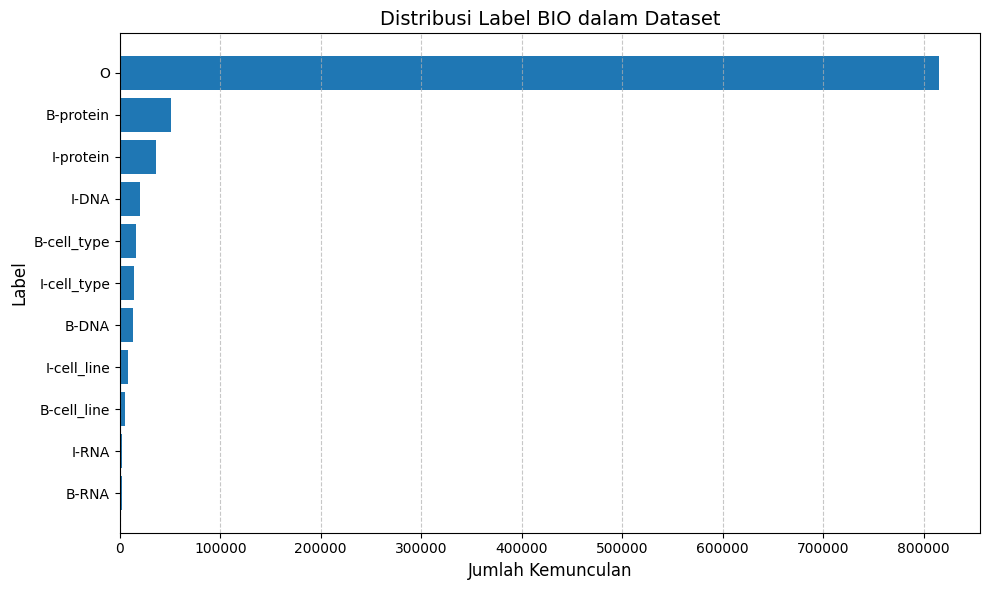

In [8]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Hitung distribusi label
all_labels = [lbl for seq in train_labels for lbl in seq]
label_dist = pd.DataFrame(Counter(all_labels).most_common(), columns=['Label', 'Count'])

# Visualisasi distribusi label
plt.figure(figsize=(10, 6))
plt.barh(label_dist['Label'].iloc[::-1], label_dist['Count'].iloc[::-1])
plt.title("Distribusi Label BIO dalam Dataset", fontsize=14)
plt.xlabel("Jumlah Kemunculan", fontsize=12)
plt.ylabel("Label", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
# Analisis panjang kalimat untuk menentukan padding length di model NER.

sentence_lengths = [len(s) for s in train_sentences]
pd.Series(sentence_lengths).describe()

count    37092.000000
mean        26.558341
std         11.942999
min          2.000000
25%         18.000000
50%         25.000000
75%         33.000000
max        204.000000
dtype: float64

In [10]:
# Mengetahui ukuran kosakata (unik token) di dataset.
tokens = [word for seq in train_sentences for word in seq]
unique_tokens = set(tokens)

print(f"Total token dalam train: {len(tokens)}")
print(f"Total token unik: {len(unique_tokens)}")

Total token dalam train: 985102
Total token unik: 22056


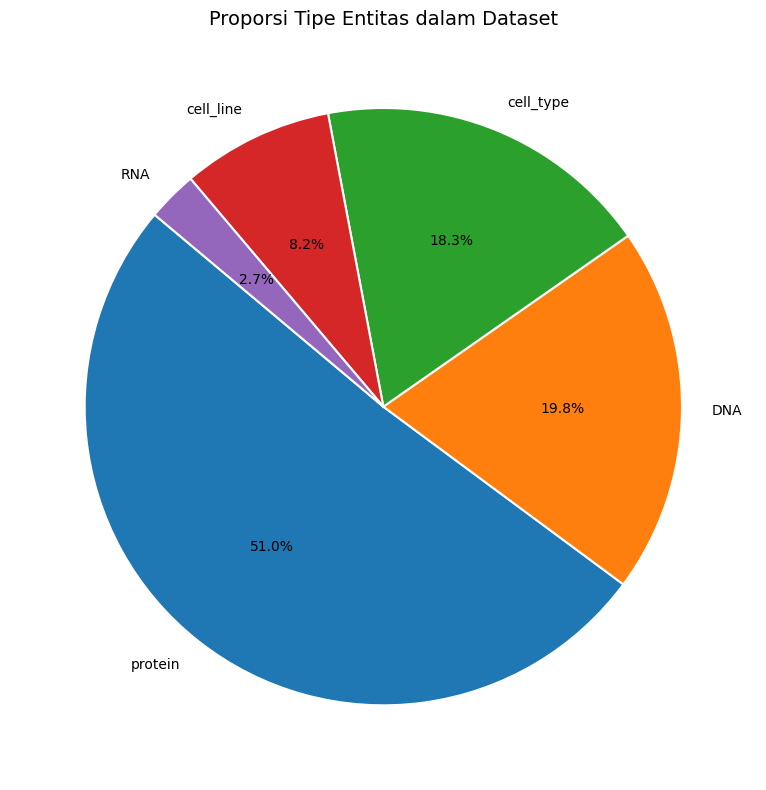

In [11]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Pisahkan tipe entitas (tanpa label O)
entity_types = [lbl.split('-')[-1] for lbl in all_labels if lbl != 'O']
entity_freq = pd.DataFrame(Counter(entity_types).most_common(), columns=['Entity Type', 'Count'])


# Visualisasi proporsi entitas
plt.figure(figsize=(8, 8))
plt.pie(
    entity_freq['Count'],
    labels=entity_freq['Entity Type'],
    autopct='%1.1f%%',  
    startangle=140,     
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title("Proporsi Tipe Entitas dalam Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Preprocessing

In [12]:
# Dataset khusus untuk Named Entity Recognition (NER)
# Mengubah data token dan label menjadi bentuk tensor agar bisa diproses oleh model PyTorch
class NERDataset(Dataset):
    def __init__(self, examples: List[Tuple[List[str], List[str]]],
                 word_vocab, char_vocab, label_vocab, max_word_len=30):
        # Menyimpan data dan kamus (vocabulary) untuk kata, karakter, dan label
        self.examples = examples
        self.wv = word_vocab
        self.cv = char_vocab
        self.lv = label_vocab
        self.max_word_len = max_word_len

    def __len__(self):
        # Mengembalikan jumlah contoh dalam dataset
        return len(self.examples)

    def token_to_id(self, token):
        # Mengubah token menjadi ID berdasarkan word_vocab
        # Jika token tidak ada di kamus → gunakan token UNK (unknown)
        return self.wv.get(token, self.wv[UNK])

    def chars_to_ids(self, token):
        # Mengubah setiap karakter dalam token menjadi ID berdasarkan char_vocab
        ids = [self.cv.get(ch, self.cv[UNK]) for ch in token[:self.max_word_len]]
        # Menambahkan padding jika panjang kata kurang dari max_word_len
        ids = ids + [self.cv[PAD]] * (self.max_word_len - len(ids))
        return ids

    def __getitem__(self, idx):
        # Mengambil satu contoh data berdasarkan indeks
        tokens, labels = self.examples[idx]
        # Ubah kata, karakter, dan label menjadi ID tensor
        w_ids = [self.token_to_id(t) for t in tokens]
        c_ids = [self.chars_to_ids(t) for t in tokens]  # bentuk: seq_len x max_word_len
        l_ids = [self.lv[l] for l in labels]
        # Kembalikan tensor beserta panjang sekuens
        return torch.tensor(w_ids, dtype=torch.long), \
               torch.tensor(c_ids, dtype=torch.long), \
               torch.tensor(l_ids, dtype=torch.long), \
               len(tokens)


# Fungsi untuk melakukan padding pada batch data agar bisa diproses bersamaan dalam model
def ner_collate(batch):
    # batch: list berisi tuple (w_ids, c_ids, l_ids, length)
    lengths = [b[3] for b in batch]
    max_len = max(lengths)  # panjang sekuens terpanjang
    max_word_len = batch[0][1].size(1)  # panjang maksimal kata (karakter)
    
    ws, cs, ls, masks = [], [], [], []
    for w_ids, c_ids, l_ids, L in batch:
        # Padding untuk kata (word-level)
        pad_w = torch.full((max_len - L,), 0, dtype=torch.long)  # PAD index 0
        ws.append(torch.cat([w_ids, pad_w], dim=0))

        # Padding untuk karakter (char-level)
        pad_c = torch.full((max_len - L, max_word_len), 0, dtype=torch.long)
        cs.append(torch.cat([c_ids, pad_c], dim=0))

        # Padding untuk label (dengan -100 agar diabaikan oleh loss function)
        pad_l = torch.full((max_len - L,), -100, dtype=torch.long)
        ls.append(torch.cat([l_ids, pad_l], dim=0))

        # Mask menandai posisi token valid (True) dan padding (False)
        masks.append(torch.cat([
            torch.ones(L, dtype=torch.bool),
            torch.zeros(max_len - L, dtype=torch.bool)
        ], dim=0))

    # Menggabungkan semua batch jadi tensor
    return torch.stack(ws), torch.stack(cs), torch.stack(ls), torch.stack(masks)

In [13]:
PAD = "<PAD>"   # Token khusus untuk padding
UNK = "<UNK>"   # Token khusus untuk kata tak dikenal (unknown)

# 1️⃣ Membuat Word Vocabulary
all_words = {w for s in train_sentences for w in s}
word_vocab = {w: i + 2 for i, w in enumerate(all_words)}  # reserve 0=PAD, 1=UNK
word_vocab["<PAD>"] = 0
word_vocab["<UNK>"] = 1

# 2️⃣ Membuat Character Vocabulary
all_chars = {ch for w in all_words for ch in w}
char_vocab = {c: i + 2 for i, c in enumerate(all_chars)}
char_vocab["<PAD>"] = 0
char_vocab["<UNK>"] = 1

# 3️⃣ Membuat Label Vocabulary
all_labels = {l for seq in train_labels for l in seq}
label_vocab = {l: i for i, l in enumerate(sorted(all_labels))}

# 4️⃣ Membungkus Data ke dalam Dataset PyTorch
train_examples = list(zip(train_sentences, train_labels))
test_examples  = list(zip(test_sentences, test_labels))

train_dataset = NERDataset(train_examples, word_vocab, char_vocab, label_vocab)
test_dataset  = NERDataset(test_examples, word_vocab, char_vocab, label_vocab)

# 5️⃣ Membuat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=ner_collate)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=ner_collate)

# 6️⃣ Mengecek Bentuk Data Batch
for ws, cs, ls, masks in train_loader:
    print("Word IDs:", ws.shape)   
    print("Char IDs:", cs.shape)   
    print("Label IDs:", ls.shape)  
    print("Masks:", masks.shape)   
    break

Word IDs: torch.Size([32, 46])
Char IDs: torch.Size([32, 46, 30])
Label IDs: torch.Size([32, 46])
Masks: torch.Size([32, 46])


In [14]:
class CharCNNWordBiLSTM(nn.Module):
    def __init__(self,
                 vocab_size,
                 char_vocab_size,
                 label_size,
                 word_emb_dim=200,
                 char_emb_dim=30,
                 char_out_channels=50,
                 char_kernel_size=3,
                 lstm_hidden=256,
                 lstm_layers=1,
                 dropout=0.3,
                 pretrained_word_emb=None):
        super().__init__()

        # 1. Membuat embedding untuk kata (word-level)
        #    Setiap kata diwakili oleh vektor berdimensi word_emb_dim.
        #    Jika ada embedding pretrained (misal GloVe), maka bobotnya diganti sesuai pretrained tersebut.
        self.word_emb = nn.Embedding(vocab_size, word_emb_dim, padding_idx=0)
        if pretrained_word_emb is not None:
            self.word_emb.weight.data[:pretrained_word_emb.shape[0]] = torch.tensor(pretrained_word_emb)

        # 2. Membuat embedding untuk karakter (char-level) dan CNN untuk ekstraksi fitur morfologi
        #    CNN di sini menangkap pola huruf seperti akhiran atau awalan yang sering muncul.
        self.char_emb = nn.Embedding(char_vocab_size, char_emb_dim, padding_idx=0)
        self.char_cnn = nn.Conv1d(in_channels=char_emb_dim,
                                  out_channels=char_out_channels,
                                  kernel_size=char_kernel_size,
                                  padding=1)

        # 3. Menyiapkan dropout untuk mencegah overfitting.
        #    input_dim = gabungan fitur dari word embedding + karakter CNN.
        self.dropout = nn.Dropout(dropout)
        input_dim = word_emb_dim + char_out_channels

        # 4. Membuat BiLSTM untuk menangkap konteks dua arah (dari kiri dan kanan).
        #    Dibagi dua karena BiLSTM punya dua arah, jadi tiap arah hanya punya setengah dimensi dari total hidden.
        self.bilstm = nn.LSTM(input_dim,
                              lstm_hidden // 2,
                              num_layers=lstm_layers,
                              batch_first=True,
                              bidirectional=True)

        # 5. Membuat lapisan klasifikasi linear untuk menghasilkan prediksi label per token.
        #    Output dari LSTM (konteksual) akan diproyeksikan ke jumlah kelas label.
        self.classifier = nn.Linear(lstm_hidden, label_size)

    def forward(self, w_ids, c_ids, mask=None):
        # 6. Embedding kata: mengubah indeks kata menjadi vektor kata
        #    Dimensi output: (batch_size, seq_len, word_emb_dim)
        bsz, seq_len = w_ids.size()
        word_emb = self.word_emb(w_ids)

        # 7. Embedding karakter + CNN + MaxPooling
        #    Setiap kata terdiri dari beberapa karakter → CNN mengekstrak pola antar huruf,
        #    kemudian max pooling mengambil fitur paling dominan untuk tiap kata.
        b_s, s_l, max_w = c_ids.size()
        ch = c_ids.view(-1, max_w)
        ch_emb = self.char_emb(ch)
        ch_emb = ch_emb.transpose(1, 2)
        ch_conv = self.char_cnn(ch_emb)
        ch_pool = torch.max(ch_conv, dim=2)[0]
        ch_pool = ch_pool.view(b_s, s_l, -1)

        # 8. Menggabungkan fitur dari word dan char level → lalu masuk ke BiLSTM
        #    Dropout diterapkan sebelum LSTM untuk regularisasi.
        x = torch.cat([word_emb, ch_pool], dim=2)
        x = self.dropout(x)
        lstm_out, _ = self.bilstm(x)

        # 9. Output dari BiLSTM diproyeksikan ke ruang label dengan Linear layer.
        #    Dropout sekali lagi untuk stabilisasi training.
        logits = self.classifier(self.dropout(lstm_out))
        return logits

In [15]:
# Gunakan GPU jika tersedia, jika tidak maka pakai CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inisialisasi model CharCNNWordBiLSTM dan pindahkan ke device
model = CharCNNWordBiLSTM(
    vocab_size=len(word_vocab),        # Jumlah kata unik
    char_vocab_size=len(char_vocab),   # Jumlah karakter unik
    label_size=len(label_vocab),       # Jumlah label kelas
    word_emb_dim=200,                  # Dimensi embedding kata
    char_emb_dim=30,                   # Dimensi embedding karakter
    char_out_channels=50,              # Output CNN karakter
    lstm_hidden=256,                   # Ukuran hidden LSTM
    dropout=0.3                        # Dropout rate
).to(device)                           # Jalankan di GPU/CPU

In [16]:
# Fungsi loss untuk klasifikasi (abaikan label -100)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

# Optimizer AdamW untuk memperbarui bobot model
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

In [17]:
def train_until_converge(
    model, dataloader, optimizer, criterion, device, 
    target_loss=0.005, patience=2
):
    """
    Melatih model hingga loss rata-rata < target_loss 
    ATAU ketika akurasi menurun selama 'patience' epoch berturut-turut.
    """
    model.train()
    epoch = 0
    best_accuracy = 0.0
    no_improve_epochs = 0

    while True:  # loop tanpa batas
        epoch += 1
        total_loss = 0.0
        correct = 0
        total = 0

        for ws, cs, ls, masks in dataloader:
            ws, cs, ls, masks = ws.to(device), cs.to(device), ls.to(device), masks.to(device)

            optimizer.zero_grad()
            logits = model(ws, cs, mask=masks)

            loss = criterion(logits.view(-1, logits.size(-1)), ls.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Hitung akurasi (prediksi vs label)
            preds = logits.argmax(dim=-1)
            mask_flat = masks.view(-1) == 1  # hanya hitung token valid
            correct += (preds.view(-1)[mask_flat] == ls.view(-1)[mask_flat]).sum().item()
            total += mask_flat.sum().item()

        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total if total > 0 else 0

        print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, Accuracy: {accuracy:.4f}")

        # Kondisi berhenti otomatis
        if avg_loss <= target_loss:
            print(f"raining selesai")
            break

        # Early stopping kalau akurasi menurun
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1

        if no_improve_epochs >= patience:
            print(f"Training dihentikan")
            break

In [18]:
train_until_converge(model, train_loader, optimizer, criterion, device)

Epoch 1, Loss: 0.257042, Accuracy: 0.9235
Epoch 2, Loss: 0.101696, Accuracy: 0.9668
Epoch 3, Loss: 0.068478, Accuracy: 0.9777
Epoch 4, Loss: 0.051174, Accuracy: 0.9833
Epoch 5, Loss: 0.040177, Accuracy: 0.9868
Epoch 6, Loss: 0.033062, Accuracy: 0.9892
Epoch 7, Loss: 0.027841, Accuracy: 0.9908
Epoch 8, Loss: 0.023857, Accuracy: 0.9921
Epoch 9, Loss: 0.020723, Accuracy: 0.9931
Epoch 10, Loss: 0.018557, Accuracy: 0.9938
Epoch 11, Loss: 0.016290, Accuracy: 0.9946
Epoch 12, Loss: 0.015085, Accuracy: 0.9949
Epoch 13, Loss: 0.013497, Accuracy: 0.9954
Epoch 14, Loss: 0.012270, Accuracy: 0.9958
Epoch 15, Loss: 0.011222, Accuracy: 0.9962
Epoch 16, Loss: 0.010494, Accuracy: 0.9965
Epoch 17, Loss: 0.009784, Accuracy: 0.9966
Epoch 18, Loss: 0.009413, Accuracy: 0.9968
Epoch 19, Loss: 0.008639, Accuracy: 0.9970
Epoch 20, Loss: 0.008178, Accuracy: 0.9972
Epoch 21, Loss: 0.007621, Accuracy: 0.9973
Epoch 22, Loss: 0.007382, Accuracy: 0.9975
Epoch 23, Loss: 0.007048, Accuracy: 0.9976
Epoch 24, Loss: 0.00

In [19]:
from seqeval.metrics import classification_report

def evaluate_seqeval(model, dataloader, id2label, device):
    model.eval()  # Mode evaluasi (tanpa dropout)
    y_true, y_pred = [], []
    
    with torch.no_grad():  # Nonaktifkan gradien saat evaluasi
        for ws, cs, ls, masks in dataloader:
            ws, cs, ls, masks = ws.to(device), cs.to(device), ls.to(device), masks.to(device)
            logits = model(ws, cs, mask=masks)
            preds = torch.argmax(logits, dim=-1)  # Ambil label dengan skor tertinggi

            for i in range(ws.size(0)):  # Iterasi per kalimat dalam batch
                sent_len = masks[i].sum().item()  # Panjang kalimat (tanpa padding)
                gold_labels = [id2label[id.item()] for id in ls[i][:sent_len]]   # Label asli
                pred_labels = [id2label[id.item()] for id in preds[i][:sent_len]] # Label prediksi
                
                y_true.append(gold_labels)
                y_pred.append(pred_labels)

    # Tampilkan metrik evaluasi (precision, recall, F1)
    print(classification_report(y_true, y_pred, digits=2))

In [20]:
# Membalik label_vocab agar id -> label
id2label = {v: k for k, v in label_vocab.items()}

# Evaluasi model menggunakan data test
evaluate_seqeval(model, test_loader, id2label, device)

              precision    recall  f1-score   support

         DNA       0.76      0.79      0.78      1622
         RNA       0.88      0.66      0.76       322
   cell_line       0.85      0.79      0.82       808
   cell_type       0.88      0.87      0.87      4140
     protein       0.85      0.83      0.84     10504

   micro avg       0.85      0.83      0.84     17396
   macro avg       0.84      0.79      0.81     17396
weighted avg       0.85      0.83      0.84     17396

